In [ ]:
# !pip install "numpy>=1.26.0,<2.1.0" xgboost pandas scikit-learn matplotlib --force-reinstall

import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, confusion_matrix
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
import re
from tqdm import trange
from datasets import load_dataset


SEED = 42
np.random.seed(SEED)

In [ ]:

ds_level1 = load_dataset(
    "Quandela/Challenge_Swaptions",
    data_files="level-1_Future_prediction/train.csv",
    split="train",
)
print(ds_level1)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

train.csv: 0.00B [00:00, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Dataset({
    features: ['Date', 'Tenor : 1; Maturity : 0.0833333333333333', 'Tenor : 2; Maturity : 0.0833333333333333', 'Tenor : 3; Maturity : 0.0833333333333333', 'Tenor : 4; Maturity : 0.0833333333333333', 'Tenor : 5; Maturity : 0.0833333333333333', 'Tenor : 6; Maturity : 0.0833333333333333', 'Tenor : 7; Maturity : 0.0833333333333333', 'Tenor : 8; Maturity : 0.0833333333333333', 'Tenor : 9; Maturity : 0.0833333333333333', 'Tenor : 10; Maturity : 0.0833333333333333', 'Tenor : 15; Maturity : 0.0833333333333333', 'Tenor : 20; Maturity : 0.0833333333333333', 'Tenor : 25; Maturity : 0.0833333333333333', 'Tenor : 30; Maturity : 0.0833333333333333', 'Tenor : 1; Maturity : 0.25', 'Tenor : 2; Maturity : 0.25', 'Tenor : 3; Maturity : 0.25', 'Tenor : 4; Maturity : 0.25', 'Tenor : 5; Maturity : 0.25', 'Tenor : 6; Maturity : 0.25', 'Tenor : 7; Maturity : 0.25', 'Tenor : 8; Maturity : 0.25', 'Tenor : 9; Maturity : 0.25', 'Tenor : 10; Maturity : 0.25', 'Tenor : 15; Maturity : 0.25', 'Tenor : 20; M

Classical Training:   0%|          | 0/100 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/optim/lr_scheduler.py:1694: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  current = float(metrics)
Classical Training: 100%|██████████| 100/100 [00:12<00:00,  8.18it/s]


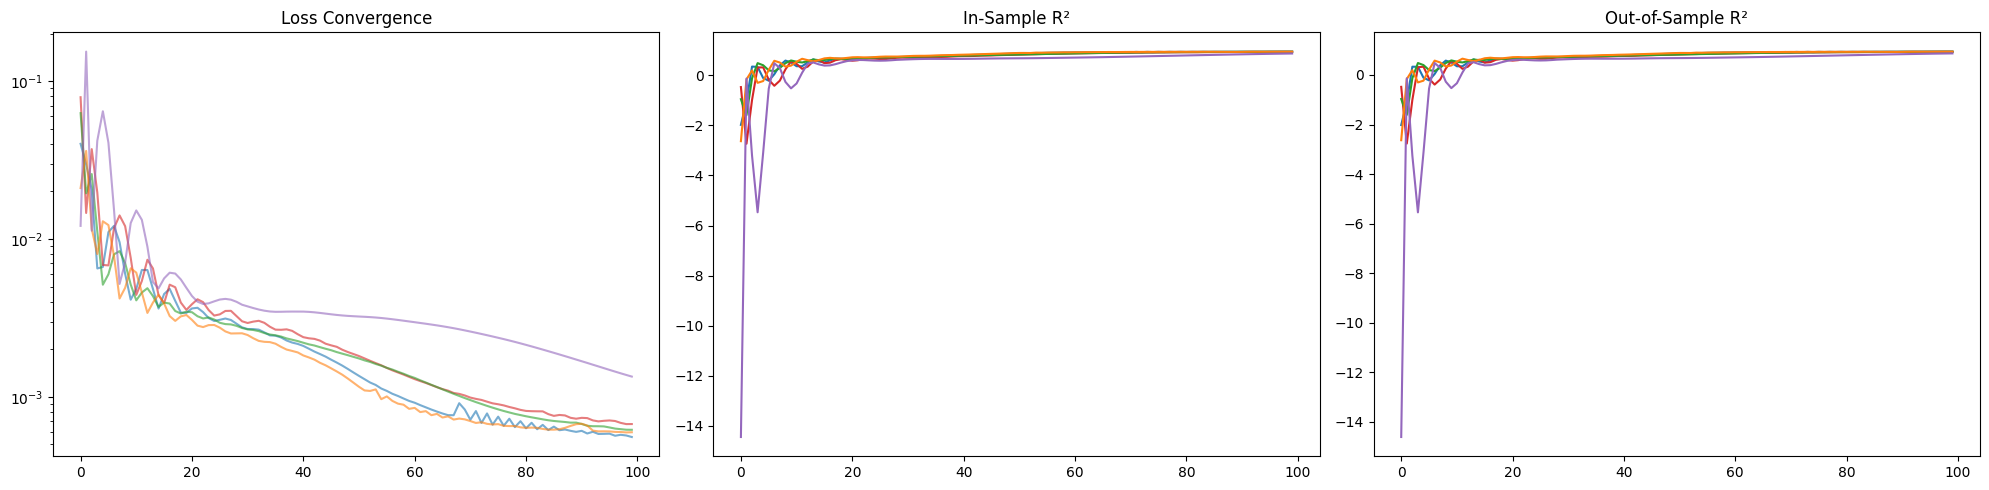

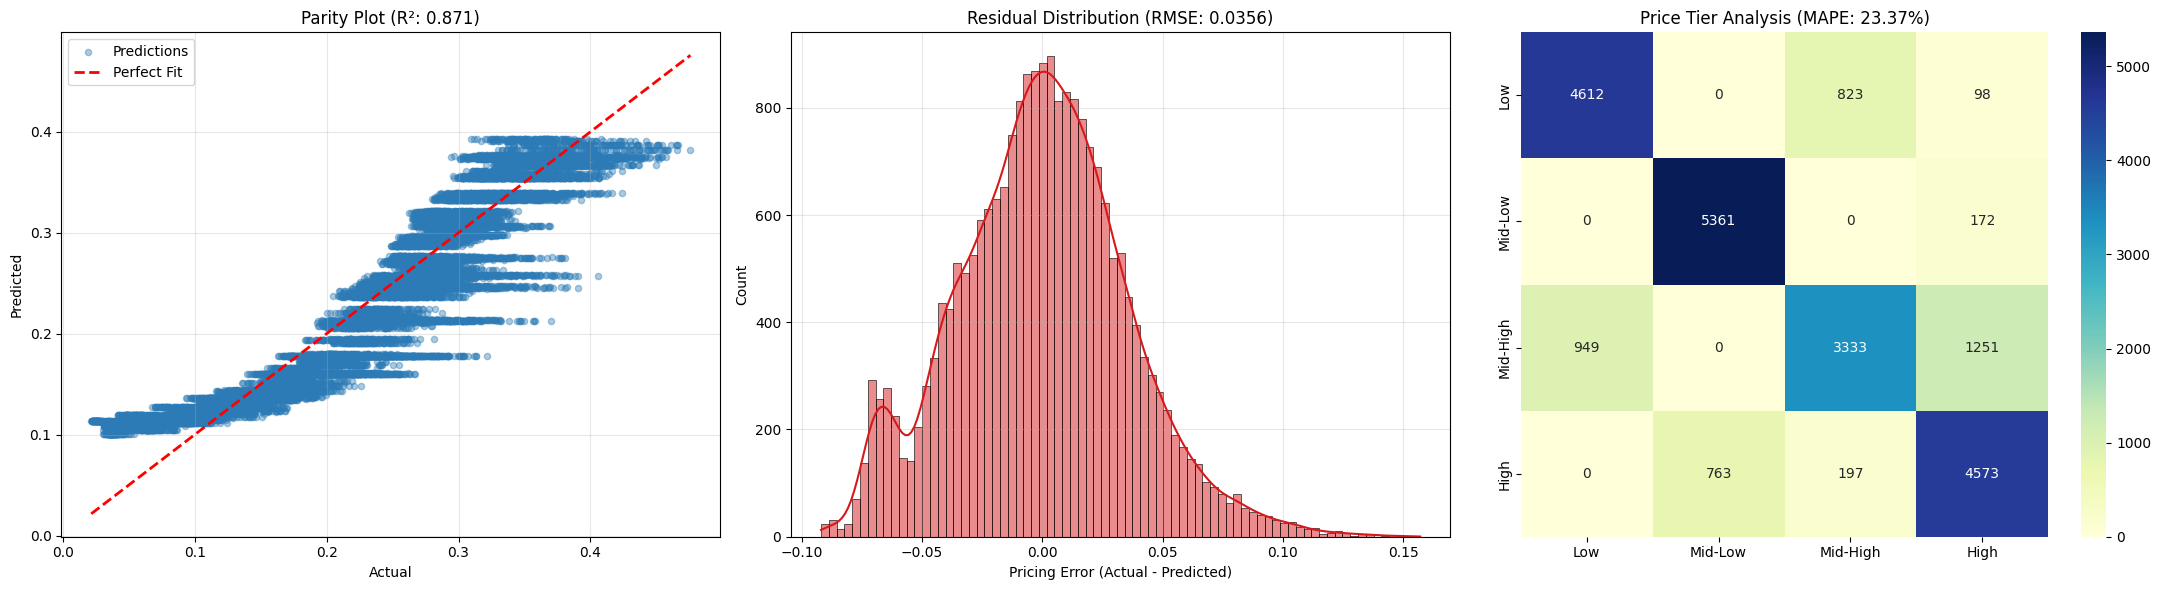


Aggregate Test R²: 0.9250 ± 0.0272
Aggregate Test MAPE: 15.28% ± 4.06%


In [ ]:

#load data
ds_level1 = load_dataset("Quandela/Challenge_Swaptions", data_files="level-1_Future_prediction/train.csv", split="train")
df_wide = ds_level1.to_pandas()
df_melted = df_wide.melt(id_vars=['Date'], var_name='Combo', value_name='Price')

def extract_params(row):
    match = re.search(r"Tenor : (\d+\.?\d*); Maturity : (\d+\.?\d*)", str(row))
    return (float(match.group(1)), float(match.group(2))) if match else (None, None)

df_melted[['Tenor', 'Maturity']] = df_melted['Combo'].apply(lambda x: pd.Series(extract_params(x)))
df_final = df_melted.dropna()

# Model architecture
class ClassicalPricer(nn.Module):
    def __init__(self):
        super(ClassicalPricer, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )
    def forward(self, x):
        return self.net(x)

# Training
def train_model_regression(model, x_train, x_test, y_train, y_test):
    optimizer = optim.Adam(model.parameters(), lr=0.01, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5, factor=0.5)
    loss_fn = nn.MSELoss()

    loss_history, train_r2_history, test_r2_history = [], [], []

    for epoch in trange(100, desc="Classical Training"):
        model.train()
        optimizer.zero_grad()
        output = model(x_train)
        loss = loss_fn(output, y_train)
        loss.backward()
        optimizer.step()
        loss_history.append(loss.item())

        model.eval()
        with torch.no_grad():
            p_train = model(x_train).numpy()
            p_test = model(x_test).numpy()
            train_r2_history.append(r2_score(y_train.numpy(), p_train))
            test_r2_history.append(r2_score(y_test.numpy(), p_test))
        scheduler.step(loss)

    # Prepare data for detailed plotting (last run data)
    final_pred = model(x_test).detach().numpy()
    final_true = y_test.numpy()
    final_mape = np.mean(np.abs((final_true - final_pred) / final_true)) * 100

    return {
        "loss_history": loss_history,
        "train_r2_history": train_r2_history,
        "test_r2_history": test_r2_history,
        "final_mape": final_mape,
        "final_test_r2": test_r2_history[-1],
        "y_pred": final_pred.flatten(),
        "y_test": final_true.flatten()
    }

# 4. MULTI-RUN EXPERIMENT
all_results = {}
random_states = [42, 123, 7, 99, 10]
last_xt_raw = None # For targeting block

for i, state in enumerate(random_states):
    X = df_final[['Tenor', 'Maturity']]
    y = df_final['Price']
    xt_raw, xv_raw, yt_raw, yv_raw = train_test_split(X, y, test_size=0.2, random_state=state)
    last_xt_raw = xv_raw # Capture for later analysis

    scaler = MinMaxScaler()
    xt_s = torch.tensor(scaler.fit_transform(xt_raw), dtype=torch.float32)
    xv_s = torch.tensor(scaler.transform(xv_raw), dtype=torch.float32)
    yt_t = torch.tensor(yt_raw.values, dtype=torch.float32).view(-1, 1)
    yv_t = torch.tensor(yv_raw.values, dtype=torch.float32).view(-1, 1)

    model = ClassicalPricer()
    all_results[f"run_{i}"] = train_model_regression(model, xt_s, xv_s, yt_t, yv_t)

# 5. VISUAL ANALYTICS (CONVERGENCE & STABILITY)
fig1, axes1 = plt.subplots(1, 3, figsize=(20, 5))
colors = ["#1f77b4", "#d62728", "#2ca02c", "#ff7f0e", "#9467bd"]
for idx in range(5):
    res = all_results[f"run_{idx}"]
    axes1[0].plot(res["loss_history"], color=colors[idx], alpha=0.6)
    axes1[1].plot(res["train_r2_history"], color=colors[idx])
    axes1[2].plot(res["test_r2_history"], color=colors[idx])
axes1[0].set_yscale('log'); axes1[0].set_title("Loss Convergence")
axes1[1].set_title("In-Sample R²"); axes1[2].set_title("Out-of-Sample R²")
plt.tight_layout(); plt.show()


last_run = all_results["run_4"]
y_test, y_pred = last_run["y_test"], last_run["y_pred"]
r2, mape = last_run["final_test_r2"], last_run["final_mape"]
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

fig2 = plt.figure(figsize=(22, 6))
#  Parity Plot
ax1 = fig2.add_subplot(131)
ax1.scatter(y_test, y_pred, alpha=0.4, color='#2c7bb6', s=20, label='Predictions')
ax1.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Fit')
ax1.set_title(f"Parity Plot (R²: {r2:.3f})"); ax1.set_xlabel("Actual"); ax1.set_ylabel("Predicted")
ax1.legend(); ax1.grid(True, alpha=0.3)

# Residual Distribution
ax2 = fig2.add_subplot(132)
residuals = y_test - y_pred
sns.histplot(residuals, kde=True, ax=ax2, color='#d7191c')
ax2.set_title(f"Residual Distribution (RMSE: {rmse:.4f})")
ax2.set_xlabel("Pricing Error (Actual - Predicted)"); ax2.grid(True, alpha=0.3)

# Binned Confusion Matrix
ax3 = fig2.add_subplot(133)
y_test_bins, bins = pd.qcut(y_test, q=4, labels=['Low', 'Mid-Low', 'Mid-High', 'High'], retbins=True)
y_pred_bins = pd.cut(y_pred, bins=bins, labels=['Low', 'Mid-Low', 'Mid-High', 'High'], include_lowest=True)
cm = confusion_matrix(y_test_bins, y_pred_bins.fillna('Low'))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', ax=ax3,
            xticklabels=['Low', 'Mid-Low', 'Mid-High', 'High'], yticklabels=['Low', 'Mid-Low', 'Mid-High', 'High'])
ax3.set_title(f"Price Tier Analysis (MAPE: {mape:.2f}%)")
plt.tight_layout(); plt.show()

# Metrics
summary = {
    "r2_mean": np.mean([all_results[f"run_{i}"]["final_test_r2"] for i in range(5)]),
    "r2_std": np.std([all_results[f"run_{i}"]["final_test_r2"] for i in range(5)]),
    "mape_mean": np.mean([all_results[f"run_{i}"]["final_mape"] for i in range(5)]),
    "mape_std": np.std([all_results[f"run_{i}"]["final_mape"] for i in range(5)]),
}
print(f"\nAggregate Test R²: {summary['r2_mean']:.4f} ± {summary['r2_std']:.4f}")
print(f"Aggregate Test MAPE: {summary['mape_mean']:.2f}% ± {summary['mape_std']:.2f}%")

Training MLP Models...
Training RNN Models...

--- MLP PERFORMANCE ---


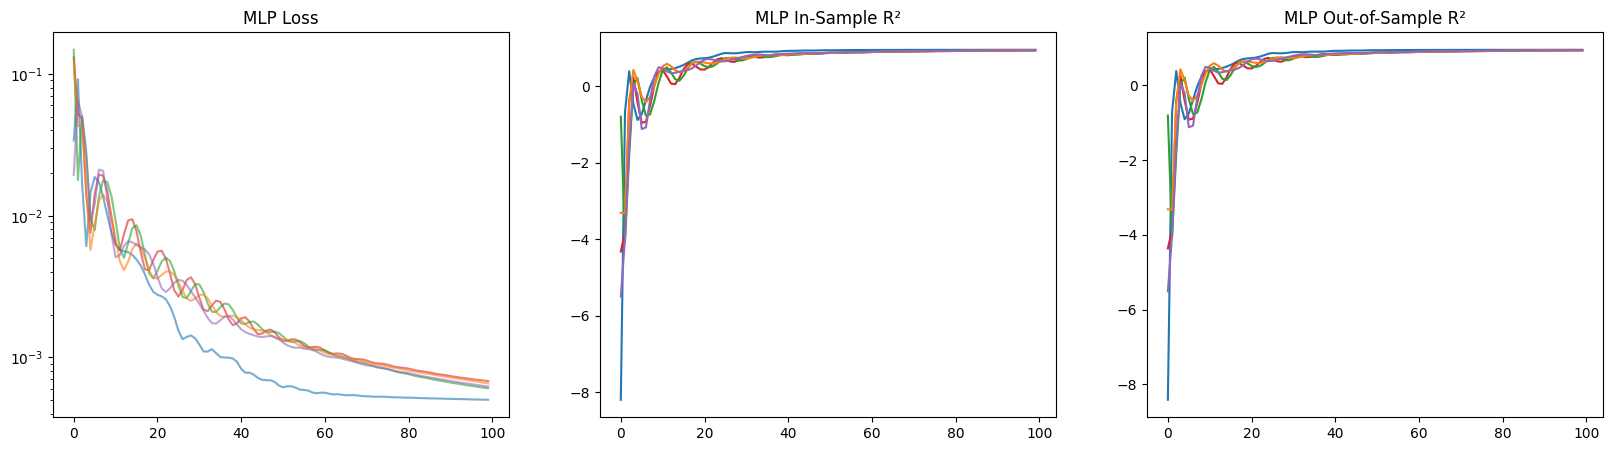

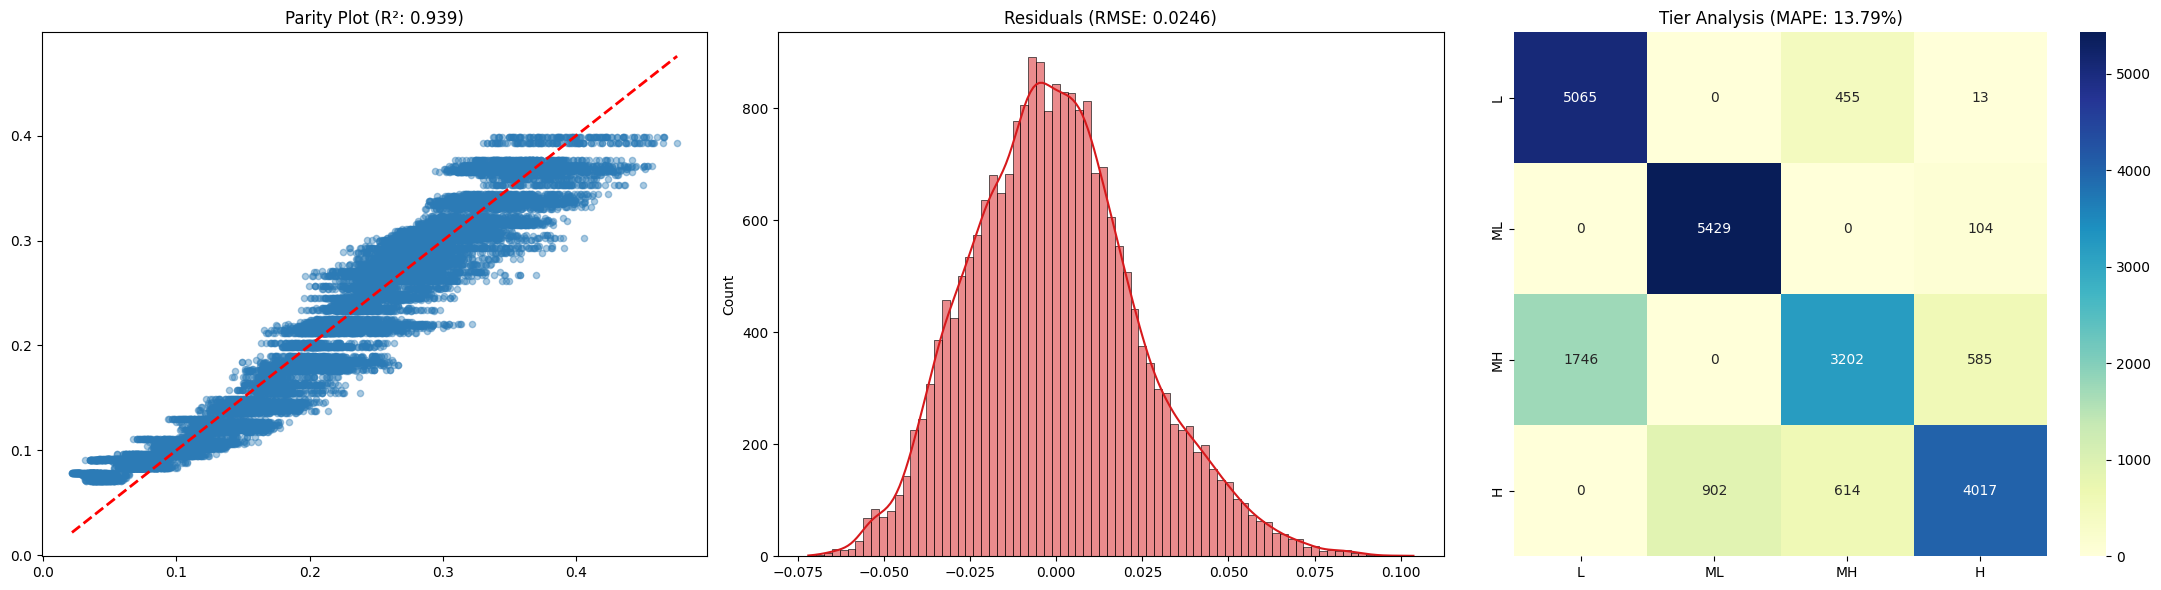


MLP Aggregate Test R²: 0.9390 ± 0.0053
MLP Aggregate Test MAPE: 13.64% ± 1.75%

--- RNN PERFORMANCE ---


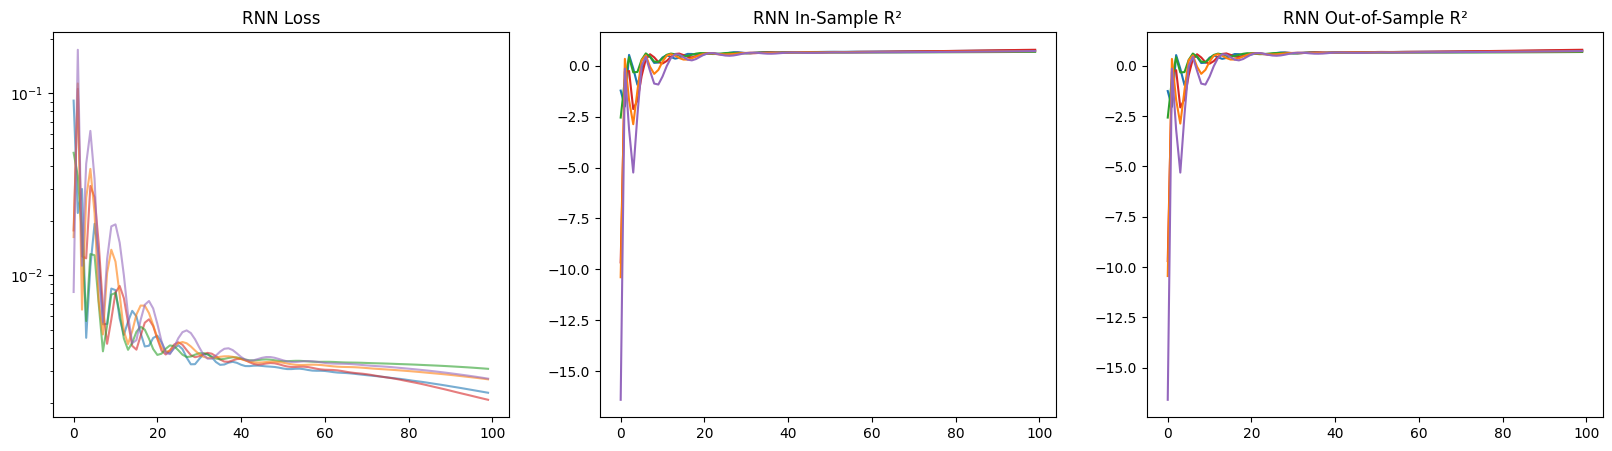

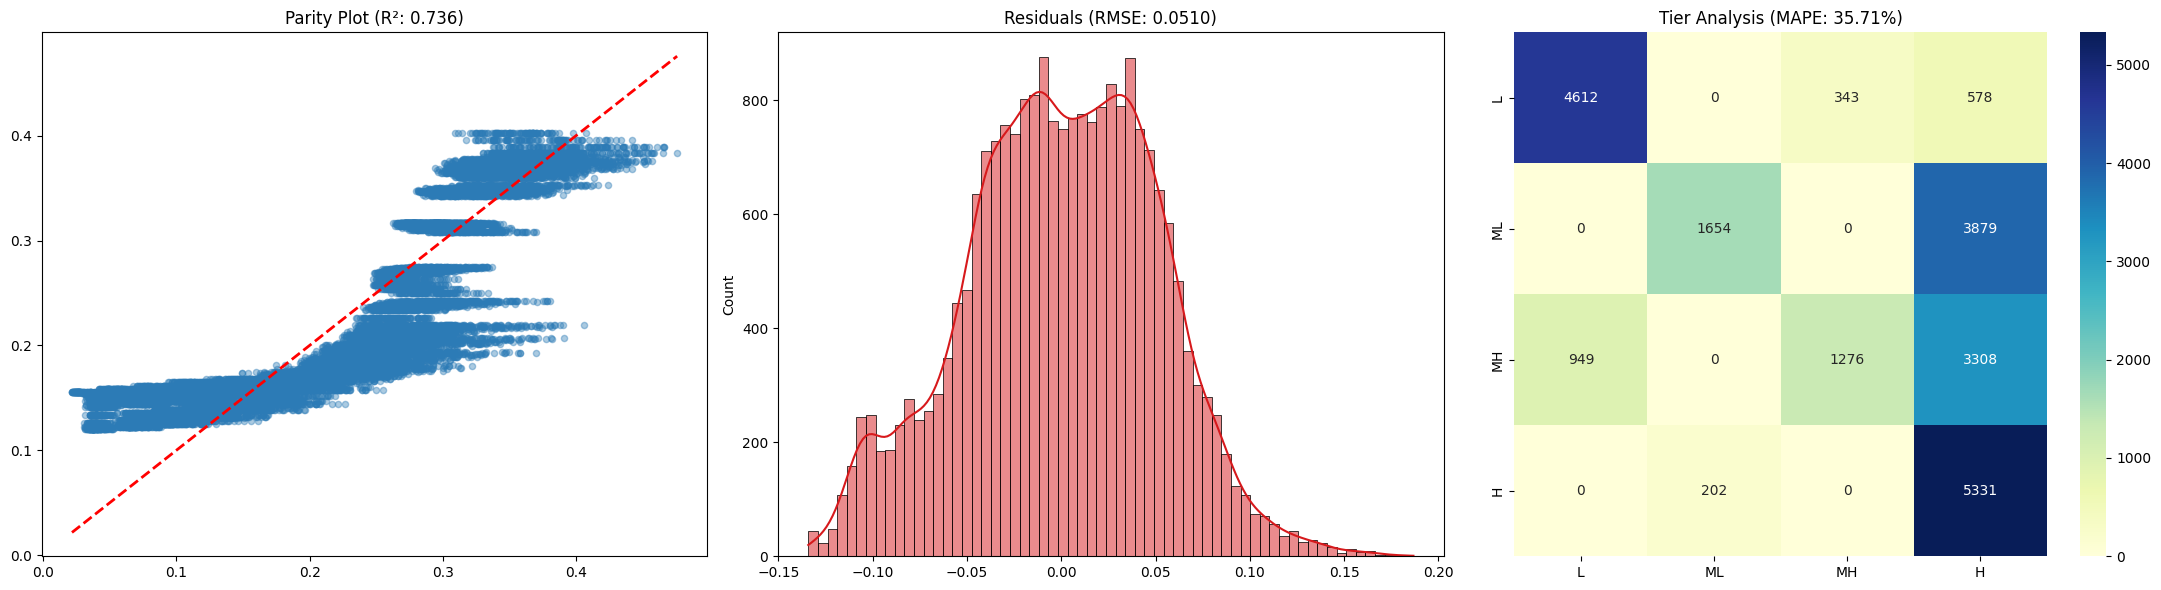


RNN Aggregate Test R²: 0.7457 ± 0.0373
RNN Aggregate Test MAPE: 34.90% ± 2.80%


In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
import re
from tqdm import trange
from sklearn.metrics import r2_score, mean_squared_error, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from datasets import load_dataset

# 1. DATA PREPARATION
ds_level1 = load_dataset("Quandela/Challenge_Swaptions", data_files="level-1_Future_prediction/train.csv", split="train")
df_wide = ds_level1.to_pandas()
df_melted = df_wide.melt(id_vars=['Date'], var_name='Combo', value_name='Price')

def extract_params(row):
    match = re.search(r"Tenor : (\d+\.?\d*); Maturity : (\d+\.?\d*)", str(row))
    return (float(match.group(1)), float(match.group(2))) if match else (None, None)

df_melted[['Tenor', 'Maturity']] = df_melted['Combo'].apply(lambda x: pd.Series(extract_params(x)))
df_final = df_melted.dropna()

#Architecture
class MLP_Pricer(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 64), nn.ReLU(),
            nn.Linear(64, 64), nn.ReLU(),
            nn.Linear(64, 1)
        )
    def forward(self, x): return self.net(x)

class RNN_Pricer(nn.Module):
    def __init__(self):
        super().__init__()
        # Input size 1 (processed one by one), hidden 32
        self.rnn = nn.RNN(input_size=1, hidden_size=32, num_layers=2, batch_first=True)
        self.fc = nn.Linear(32, 1)
    def forward(self, x):
        # x shape: [batch, 2] -> [batch, 2, 1]
        x = x.unsqueeze(-1)
        out, _ = self.rnn(x)
        return self.fc(out[:, -1, :]) # Take last sequence output

# Train loop set up
def run_benchmark(ModelClass, X, y, seeds):
    all_runs = {}
    for i, seed in enumerate(seeds):
        xt_raw, xv_raw, yt_raw, yv_raw = train_test_split(X, y, test_size=0.2, random_state=seed)

        scaler = StandardScaler()
        xt_s = torch.tensor(scaler.fit_transform(xt_raw), dtype=torch.float32)
        xv_s = torch.tensor(scaler.transform(xv_raw), dtype=torch.float32)
        yt_t = torch.tensor(yt_raw.values, dtype=torch.float32).view(-1, 1)
        yv_t = torch.tensor(yv_raw.values, dtype=torch.float32).view(-1, 1)

        model = ModelClass()
        optimizer = optim.Adam(model.parameters(), lr=0.01)
        loss_fn = nn.MSELoss()

        loss_hist, tr_r2, te_r2 = [], [], []

        for epoch in range(100):
            model.train()
            optimizer.zero_grad()
            pred = model(xt_s)
            loss = loss_fn(pred, yt_t)
            loss.backward(); optimizer.step()
            loss_hist.append(loss.item())

            model.eval()
            with torch.no_grad():
                tr_r2.append(r2_score(yt_t.numpy(), model(xt_s).numpy()))
                p_te = model(xv_s).numpy()
                te_r2.append(r2_score(yv_t.numpy(), p_te))

        all_runs[f"run_{i}"] = {
            "loss_history": loss_hist, "train_r2_history": tr_r2, "test_r2_history": te_r2,
            "y_test": yv_t.numpy().flatten(), "y_pred": p_te.flatten(),
            "final_test_r2": te_r2[-1], "final_mape": np.mean(np.abs((yv_t.numpy().flatten() - p_te.flatten()) / yv_t.numpy().flatten())) * 100
        }
    return all_runs

# Train
X, y = df_final[['Tenor', 'Maturity']], df_final['Price']
random_states = [42, 123, 7, 99, 10]

print("Training MLP Models...")
mlp_results = run_benchmark(MLP_Pricer, X, y, random_states)
print("Training RNN Models...")
rnn_results = run_benchmark(RNN_Pricer, X, y, random_states)

# Plots
def plot_results(all_results, title_prefix):
    #
    fig1, axes1 = plt.subplots(1, 3, figsize=(20, 5))
    colors = ["#1f77b4", "#d62728", "#2ca02c", "#ff7f0e", "#9467bd"]
    for idx in range(5):
        res = all_results[f"run_{idx}"]
        axes1[0].plot(res["loss_history"], color=colors[idx], alpha=0.6)
        axes1[1].plot(res["train_r2_history"], color=colors[idx])
        axes1[2].plot(res["test_r2_history"], color=colors[idx])
    axes1[0].set_yscale('log'); axes1[0].set_title(f"{title_prefix} Loss")
    axes1[1].set_title(f"{title_prefix} In-Sample R²")
    axes1[2].set_title(f"{title_prefix} Out-of-Sample R²")
    plt.show()

    # Plots
    last_run = all_results["run_4"]
    y_test, y_pred = last_run["y_test"], last_run["y_pred"]
    r2, mape = last_run["final_test_r2"], last_run["final_mape"]
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    fig2 = plt.figure(figsize=(22, 6))
    ax1 = fig2.add_subplot(131)
    ax1.scatter(y_test, y_pred, alpha=0.4, color='#2c7bb6', s=20)
    ax1.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    ax1.set_title(f"Parity Plot (R²: {r2:.3f})")

    ax2 = fig2.add_subplot(132)
    sns.histplot(y_test - y_pred, kde=True, ax=ax2, color='#d7191c')
    ax2.set_title(f"Residuals (RMSE: {rmse:.4f})")

    ax3 = fig2.add_subplot(133)
    y_test_bins = pd.qcut(y_test, q=4, labels=['Low', 'Mid-Low', 'Mid-High', 'High'])
    y_pred_bins = pd.cut(y_pred, bins=pd.qcut(y_test, q=4, retbins=True)[1], labels=['Low', 'Mid-Low', 'Mid-High', 'High'], include_lowest=True)
    cm = confusion_matrix(y_test_bins, y_pred_bins.fillna('Low'))
    sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', ax=ax3, xticklabels=['L','ML','MH','H'], yticklabels=['L','ML','MH','H'])
    ax3.set_title(f"Tier Analysis (MAPE: {mape:.2f}%)")
    plt.tight_layout(); plt.show()

    # 7. AGGREGATE SUMMARY
    r2_vals = [all_results[f"run_{i}"]["final_test_r2"] for i in range(5)]
    mape_vals = [all_results[f"run_{i}"]["final_mape"] for i in range(5)]
    print(f"\n{title_prefix} Aggregate Test R²: {np.mean(r2_vals):.4f} ± {np.std(r2_vals):.4f}")
    print(f"{title_prefix} Aggregate Test MAPE: {np.mean(mape_vals):.2f}% ± {np.std(mape_vals):.2f}%")

print("\n--- MLP PERFORMANCE ---")
plot_results(mlp_results, "MLP")
print("\n--- RNN PERFORMANCE ---")
plot_results(rnn_results, "RNN")

In [ ]:
# import pandas as pd
# import numpy as np
# import torch
# import torch.nn as nn
# import torch.optim as optim
# import matplotlib.pyplot as plt
# import seaborn as sns
# import re
# from tqdm import trange
# from sklearn.metrics import r2_score, mean_squared_error, confusion_matrix
# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import MinMaxScaler
# from datasets import load_dataset
# from merlin import QuantumLayer, LexGrouping, ComputationSpace
# from merlin.builder import CircuitBuilder

# # 1. DATA PREPARATION (Identifying Put/Call-like structure)
# ds_level1 = load_dataset("Quandela/Challenge_Swaptions", data_files="level-1_Future_prediction/train.csv", split="train")
# df_wide = ds_level1.to_pandas()
# df_melted = df_wide.melt(id_vars=['Date'], var_name='Combo', value_name='Price')

# def extract_params(row):
#     match = re.search(r"Tenor : (\d+\.?\d*); Maturity : (\d+\.?\d*)", str(row))
#     return (float(match.group(1)), float(match.group(2))) if match else (None, None)

# df_melted[['Tenor', 'Maturity']] = df_melted['Combo'].apply(lambda x: pd.Series(extract_params(x)))
# df_final = df_melted.dropna()

# # 2. QRC ARCHITECTURE
# class QRC_Pricer(nn.Module):
#     def __init__(self, builder):
#         super().__init__()
#         # Quantum Reservoir (Frozen Features)
#         self.quantum_core = QuantumLayer(input_size=2, builder=builder, n_photons=6, computation_space=ComputationSpace.FOCK)
#         # Mapping ~12k Fock states to 32 learned features
#         self.grouping = LexGrouping(self.quantum_core.output_size, 32)
#         self.readout = nn.Linear(32, 1)

#     def forward(self, x):
#         with torch.no_grad(): # Core is frozen in Reservoir Computing
#             x = self.quantum_core(x)
#         x = self.grouping(x)
#         return self.readout(x)

# # 3. QRC EXPERIMENT ENGINE
# n_modes = 12
# builder = CircuitBuilder(n_modes=n_modes)
# builder.add_angle_encoding(modes=[0, 1], name="input_injection")
# builder.add_entangling_layer(name="reservoir_mesh")

# X = df_final[['Tenor', 'Maturity']]
# y = df_final['Price']
# random_states = [42, 123, 7, 99, 10]
# all_results = {}

# for i, state in enumerate(random_states):
#     xt_raw, xv_raw, yt_raw, yv_raw = train_test_split(X, y, test_size=0.2, random_state=state)
#     scaler = MinMaxScaler(feature_range=(0, np.pi)) # Phase encoding
#     xt_s = torch.tensor(scaler.fit_transform(xt_raw), dtype=torch.float32)
#     xv_s = torch.tensor(scaler.transform(xv_raw), dtype=torch.float32)
#     yt_t = torch.tensor(yt_raw.values, dtype=torch.float32).view(-1, 1)
#     yv_t = torch.tensor(yv_raw.values, dtype=torch.float32).view(-1, 1)

#     model = QRC_Pricer(builder)
#     optimizer = optim.Adam(model.parameters(), lr=0.01)
#     loss_fn = nn.MSELoss()

#     loss_hist, tr_r2, te_r2 = [], [], []
#     for epoch in range(100):
#         model.train()
#         optimizer.zero_grad(); pred = model(xt_s); loss = loss_fn(pred, yt_t)
#         loss.backward(); optimizer.step(); loss_hist.append(loss.item())
#         model.eval()
#         with torch.no_grad():
#             tr_r2.append(r2_score(yt_t.numpy(), model(xt_s).numpy()))
#             p_te = model(xv_s).numpy(); te_r2.append(r2_score(yv_t.numpy(), p_te))

#     all_results[f"run_{i}"] = {
#         "loss_history": loss_hist, "train_r2_history": tr_r2, "test_r2_history": te_r2,
#         "y_test": yv_t.numpy().flatten(), "y_pred": p_te.flatten(),
#         "final_test_r2": te_r2[-1], "final_mape": np.mean(np.abs((yv_t.numpy().flatten() - p_te.flatten()) / yv_t.numpy().flatten())) * 100
#     }

# # 4. PLOTTING SCHEMA (QRC)
# fig1, axes1 = plt.subplots(1, 3, figsize=(20, 5))
# for idx in range(5):
#     res = all_results[f"run_{idx}"]
#     axes1[0].plot(res["loss_history"], alpha=0.6); axes1[1].plot(res["train_r2_history"]); axes1[2].plot(res["test_r2_history"])
# axes1[0].set_yscale('log'); axes1[0].set_title("QRC Loss Convergence"); plt.show()

# last_run = all_results["run_4"]
# fig2 = plt.figure(figsize=(22, 6))
# ax1 = fig2.add_subplot(131); ax1.scatter(last_run["y_test"], last_run["y_pred"], alpha=0.4, color='#2c7bb6')
# ax1.plot([last_run["y_test"].min(), last_run["y_test"].max()], [last_run["y_test"].min(), last_run["y_test"].max()], 'r--')
# ax2 = fig2.add_subplot(132); sns.histplot(last_run["y_test"] - last_run["y_pred"], kde=True, ax=ax2, color='#d7191c')
# ax3 = fig2.add_subplot(133); cm = confusion_matrix(pd.qcut(last_run["y_test"], q=4, labels=[0,1,2,3]), pd.cut(last_run["y_pred"], bins=pd.qcut(last_run["y_test"], q=4, retbins=True)[1], labels=[0,1,2,3], include_lowest=True).fillna(0))
# sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', ax=ax3); plt.tight_layout(); plt.show()

ModuleNotFoundError: No module named 'merlin'

MLP Run 4: 100%|██████████| 100/100 [00:12<00:00,  8.09it/s]



MLP AGGREGATE PERFORMANCE
Mean Test R²:  0.9437 ± 0.0034
Mean Test MAPE: 12.73% ± 0.92%


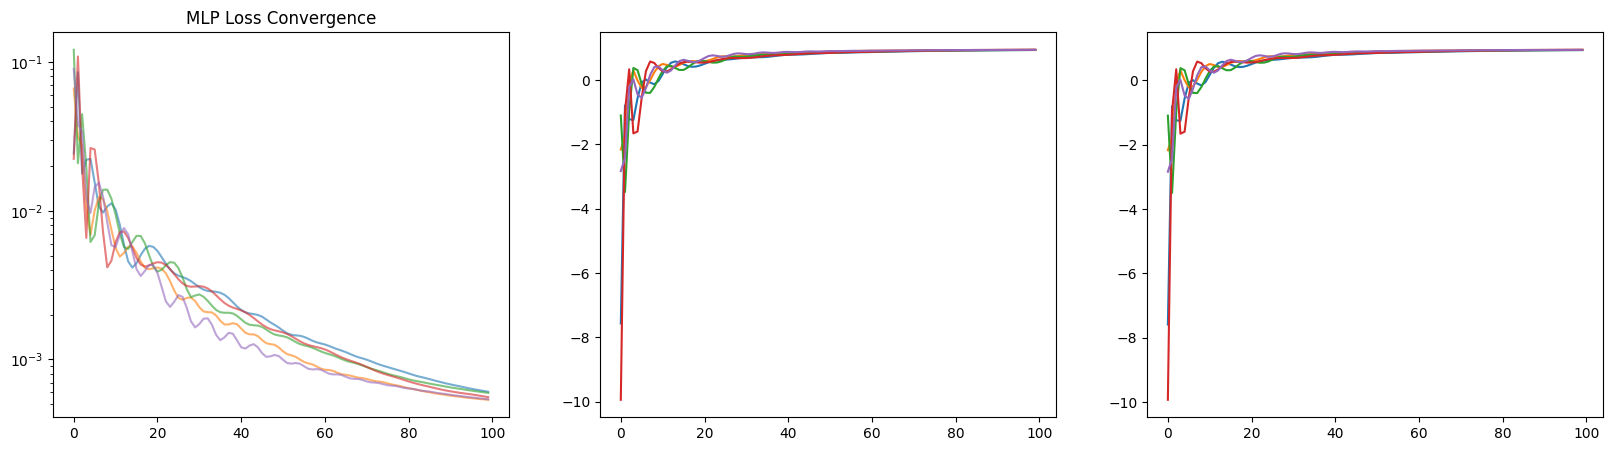

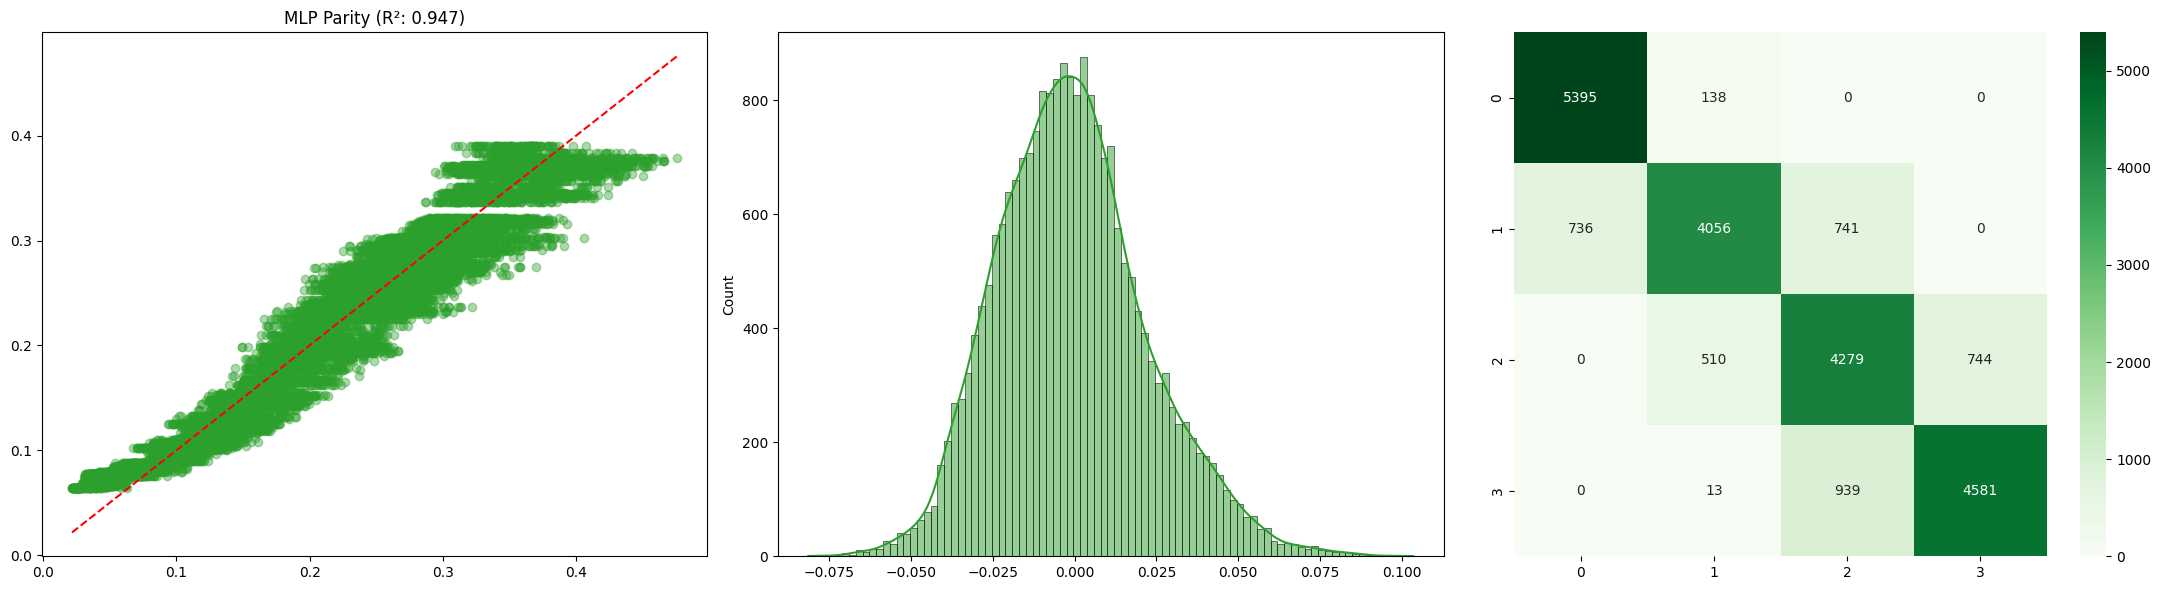

In [ ]:
# --- MLP Model
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error, confusion_matrix

Architecture
class MLP_Pricer(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 64), nn.ReLU(),
            nn.Linear(64, 64), nn.ReLU(),
            nn.Linear(64, 1)
        )
    def forward(self, x): return self.net(x)

# 2. Multi-Run Experiment
all_results_mlp = {}
random_states = [42, 123, 7, 99, 10]

for i, state in enumerate(random_states):
    xt_raw, xv_raw, yt_raw, yv_raw = train_test_split(X, y, test_size=0.2, random_state=state)
    scaler = StandardScaler()
    xt_s = torch.tensor(scaler.fit_transform(xt_raw), dtype=torch.float32)
    xv_s = torch.tensor(scaler.transform(xv_raw), dtype=torch.float32)
    yt_t = torch.tensor(yt_raw.values, dtype=torch.float32).view(-1, 1)
    yv_t = torch.tensor(yv_raw.values, dtype=torch.float32).view(-1, 1)

    model = MLP_Pricer()
    optimizer = optim.Adam(model.parameters(), lr=0.01)
    loss_fn = nn.MSELoss()

    loss_hist, tr_r2, te_r2 = [], [], []
    for epoch in trange(100, desc=f"MLP Run {i}"):
        model.train(); optimizer.zero_grad(); pred = model(xt_s); loss = loss_fn(pred, yt_t)
        loss.backward(); optimizer.step(); loss_hist.append(loss.item())

        model.eval()
        with torch.no_grad():
            tr_r2.append(r2_score(yt_t.numpy(), model(xt_s).numpy()))
            p_te = model(xv_s).numpy(); te_r2.append(r2_score(yv_t.numpy(), p_te))

    all_results_mlp[f"run_{i}"] = {
        "loss_history": loss_hist, "train_r2_history": tr_r2, "test_r2_history": te_r2,
        "y_test": yv_t.numpy().flatten(), "y_pred": p_te.flatten(),
        "final_test_r2": te_r2[-1],
        "final_mape": np.mean(np.abs((yv_t.numpy().flatten() - p_te.flatten()) / yv_t.numpy().flatten())) * 100
    }

#Metrics
mlp_r2_scores = [all_results_mlp[f"run_{i}"]["final_test_r2"] for i in range(5)]
mlp_mape_scores = [all_results_mlp[f"run_{i}"]["final_mape"] for i in range(5)]

print("\n" + "="*30)
print("MLP AGGREGATE PERFORMANCE")
print("="*30)
print(f"Mean Test R²:  {np.mean(mlp_r2_scores):.4f} ± {np.std(mlp_r2_scores):.4f}")
print(f"Mean Test MAPE: {np.mean(mlp_mape_scores):.2f}% ± {np.std(mlp_mape_scores):.2f}%")
print("="*30)


fig1, axes1 = plt.subplots(1, 3, figsize=(20, 5))
for idx in range(5):
    res = all_results_mlp[f"run_{idx}"]
    axes1[0].plot(res["loss_history"], alpha=0.6); axes1[1].plot(res["train_r2_history"]); axes1[2].plot(res["test_r2_history"])
axes1[0].set_yscale('log'); axes1[0].set_title("MLP Loss Convergence"); plt.show()

last_run = all_results_mlp["run_4"]
fig2 = plt.figure(figsize=(22, 6))
ax1 = fig2.add_subplot(131); ax1.scatter(last_run["y_test"], last_run["y_pred"], alpha=0.4, color='#2ca02c')
ax1.plot([last_run["y_test"].min(), last_run["y_test"].max()], [last_run["y_test"].min(), last_run["y_test"].max()], 'r--')
ax1.set_title(f"MLP Parity (R²: {last_run['final_test_r2']:.3f})")
ax2 = fig2.add_subplot(132); sns.histplot(last_run["y_test"] - last_run["y_pred"], kde=True, ax=ax2, color='#2ca02c')
ax3 = fig2.add_subplot(133); cm = confusion_matrix(pd.qcut(last_run["y_test"], q=4, labels=[0,1,2,3]), pd.cut(last_run["y_pred"], bins=pd.qcut(last_run["y_test"], q=4, retbins=True)[1], labels=[0,1,2,3], include_lowest=True).fillna(0))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=ax3); plt.tight_layout(); plt.show()

RNN Run 4: 100%|██████████| 100/100 [00:22<00:00,  4.43it/s]



RNN AGGREGATE PERFORMANCE
Mean Test R²:  0.7240 ± 0.0320
Mean Test MAPE: 36.48% ± 2.80%


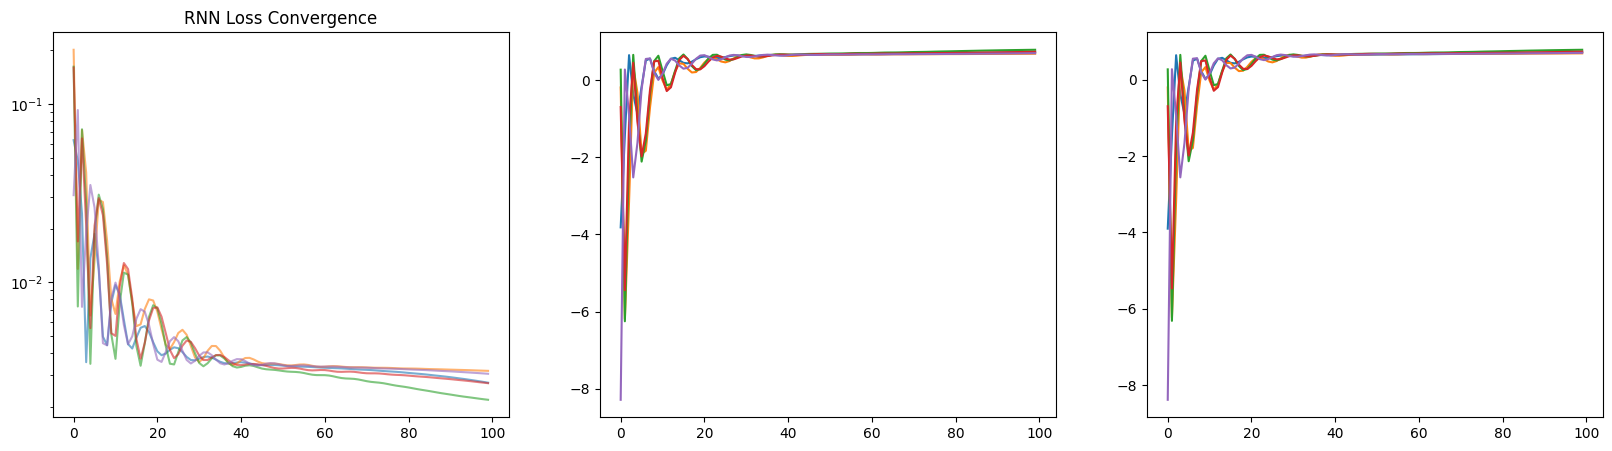

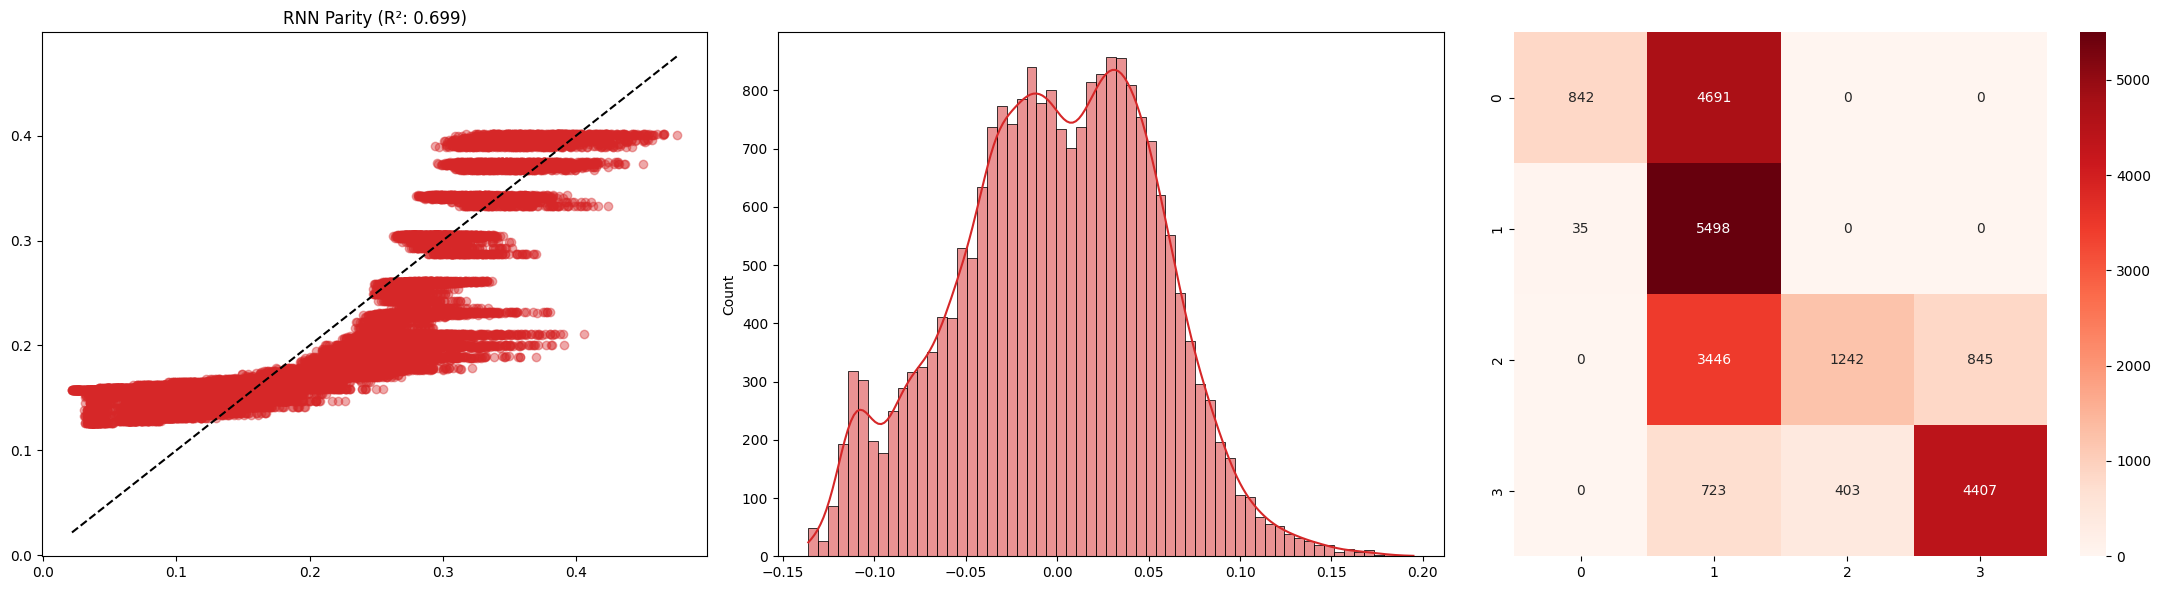

In [ ]:
# --- RNN Model
# Architecture
class RNN_Pricer(nn.Module):
    def __init__(self):
        super().__init__()
        self.rnn = nn.RNN(input_size=1, hidden_size=32, num_layers=2, batch_first=True)
        self.fc = nn.Linear(32, 1)
    def forward(self, x):
        x = x.unsqueeze(-1) # [batch, 2, 1]
        out, _ = self.rnn(x)
        return self.fc(out[:, -1, :])

#
all_results_rnn = {}
for i, state in enumerate(random_states):
    xt_raw, xv_raw, yt_raw, yv_raw = train_test_split(X, y, test_size=0.2, random_state=state)
    scaler = StandardScaler()
    xt_s = torch.tensor(scaler.fit_transform(xt_raw), dtype=torch.float32)
    xv_s = torch.tensor(scaler.transform(xv_raw), dtype=torch.float32)
    yt_t = torch.tensor(yt_raw.values, dtype=torch.float32).view(-1, 1)
    yv_t = torch.tensor(yv_raw.values, dtype=torch.float32).view(-1, 1)

    model = RNN_Pricer()
    optimizer = optim.Adam(model.parameters(), lr=0.01)
    loss_fn = nn.MSELoss()

    loss_hist, tr_r2, te_r2 = [], [], []
    for epoch in trange(100, desc=f"RNN Run {i}"):
        model.train(); optimizer.zero_grad(); pred = model(xt_s); loss = loss_fn(pred, yt_t)
        loss.backward(); optimizer.step(); loss_hist.append(loss.item())

        model.eval()
        with torch.no_grad():
            tr_r2.append(r2_score(yt_t.numpy(), model(xt_s).numpy()))
            p_te = model(xv_s).numpy(); te_r2.append(r2_score(yv_t.numpy(), p_te))

    all_results_rnn[f"run_{i}"] = {
        "loss_history": loss_hist, "train_r2_history": tr_r2, "test_r2_history": te_r2,
        "y_test": yv_t.numpy().flatten(), "y_pred": p_te.flatten(),
        "final_test_r2": te_r2[-1],
        "final_mape": np.mean(np.abs((yv_t.numpy().flatten() - p_te.flatten()) / yv_t.numpy().flatten())) * 100
    }

#Metrics
rnn_r2_scores = [all_results_rnn[f"run_{i}"]["final_test_r2"] for i in range(5)]
rnn_mape_scores = [all_results_rnn[f"run_{i}"]["final_mape"] for i in range(5)]

print("\n" + "="*30)
print("RNN AGGREGATE PERFORMANCE")
print("="*30)
print(f"Mean Test R²:  {np.mean(rnn_r2_scores):.4f} ± {np.std(rnn_r2_scores):.4f}")
print(f"Mean Test MAPE: {np.mean(rnn_mape_scores):.2f}% ± {np.std(rnn_mape_scores):.2f}%")
print("="*30)

fig1, axes1 = plt.subplots(1, 3, figsize=(20, 5))
for idx in range(5):
    res = all_results_rnn[f"run_{idx}"]
    axes1[0].plot(res["loss_history"], alpha=0.6); axes1[1].plot(res["train_r2_history"]); axes1[2].plot(res["test_r2_history"])
axes1[0].set_yscale('log'); axes1[0].set_title("RNN Loss Convergence"); plt.show()

last_run = all_results_rnn["run_4"]
fig2 = plt.figure(figsize=(22, 6))
ax1 = fig2.add_subplot(131); ax1.scatter(last_run["y_test"], last_run["y_pred"], alpha=0.4, color='#d62728')
ax1.plot([last_run["y_test"].min(), last_run["y_test"].max()], [last_run["y_test"].min(), last_run["y_test"].max()], 'k--')
ax1.set_title(f"RNN Parity (R²: {last_run['final_test_r2']:.3f})")
ax2 = fig2.add_subplot(132); sns.histplot(last_run["y_test"] - last_run["y_pred"], kde=True, ax=ax2, color='#d62728')
ax3 = fig2.add_subplot(133); cm = confusion_matrix(pd.qcut(last_run["y_test"], q=4, labels=[0,1,2,3]), pd.cut(last_run["y_pred"], bins=pd.qcut(last_run["y_test"], q=4, retbins=True)[1], labels=[0,1,2,3], include_lowest=True).fillna(0))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', ax=ax3); plt.tight_layout(); plt.show()